## EfficientNet - 512*512 center crop data

- Data Size: 약 69898장(6.6 GB)
- Label 수: 13개
- Image size: 512*512, RGB

In [40]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim import Adam
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision
from tensorboardX import SummaryWriter
from tqdm import tqdm

#### 데이터 전처리 정의

In [41]:
transforms_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### 데이터 불러오기

In [42]:
full_datasets = datasets.ImageFolder(root='../datasets/data')
full_datasets.classes

['금속캔알루미늄캔',
 '금속캔철캔',
 '비닐',
 '스티로폼',
 '유리병갈색',
 '유리병녹색',
 '유리병투명',
 '종이',
 '페트병무색단일',
 '페트병유색단일',
 '플라스틱PE',
 '플라스틱PP',
 '플라스틱PS']

#### 학습용과 시험용으로 데이터 쪼개기

In [43]:
# 학습용과 검증용 데이터셋 크기 정의
total_size = len(full_datasets)
train_size = int(total_size * 0.8)
test_size = total_size - train_size

In [44]:
train_dataset, test_dataset = torch.utils.data.random_split(
    full_datasets,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print("\n데이터셋 분할 완료.")
print(f"총 데이터 수: {total_size}")
print(f"학습용 데이터 수: {len(train_dataset)}")
print(f"검증용 데이터 수: {len(test_dataset)}")



데이터셋 분할 완료.
총 데이터 수: 69898
학습용 데이터 수: 55918
검증용 데이터 수: 13980


- 전처리 적용

In [45]:
train_dataset.dataset.trnsform = transforms_train
test_dataset.dataset.transform = transforms_test

In [46]:
train_dataset

In [47]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
1


- 미니배치 사이즈로 쪼개기

In [48]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [49]:
next(iter(train_loader))[0].shape # train_loader 첫번째 배치

torch.Size([32, 3, 224, 224])

#### 이미지 확인해 보기

In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
## 이미지 시각화를 함수로 정의

def imshow(img, title):
    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()
    

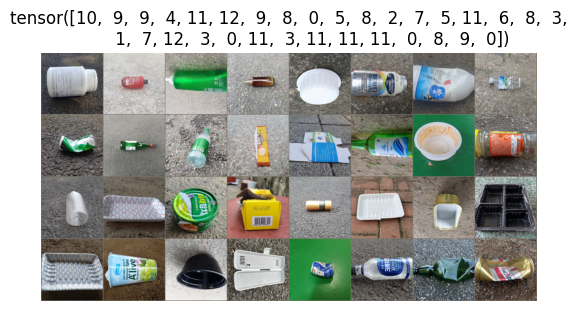

In [52]:
images, labels = next(iter(train_loader))
images_data = torchvision.utils.make_grid(images)

imshow(images_data, labels)

#### 모델 생성

In [58]:
# weights = models.EfficientNet_B0_Weights.DEFAULT
# model = models.efficientnet_b0(weights=weights)

# model

In [56]:
def build_efficientnet_model(num_classes=13):
    # EfficientNet_B0_Weights.DEFAULT는 ImageNet으로 사전 학습된 기본 가중치를 의미
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    # 모든 레이어의 가중치를 재학습 가능하도록 설정
    # torchvision의 모델은 기본적으로 requires_grad=True 이므로 이코드는 생략 가능하지만 명시적으로 표시한거
    for param in model.parameters():
        param.requires_grad = True
    
    # 마지막 분류 레이어(classifier) 수정
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features=num_features, out_features=num_classes)

    return model


In [57]:
my_model = build_efficientnet_model(13)

print(my_model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

writer = SummaryWriter()

lr = 1e-3
optimizer = torch.optim.Adam(my_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
epochs = 2
step = 0

my_model.to(device)

for epoch in range(epochs):
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        preds = my_model(images)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        writer.add_scalar("Loss/train", loss.item(), step)
        step += 1
    
    print(f"{epoch}: epoch loss: {loss.item()}")




100%|██████████| 1748/1748 [11:47<00:00,  2.47it/s]


tensor(0.6148, device='cuda:0', grad_fn=<NllLossBackward0>)
0: epoch loss: 0.6148014068603516


100%|██████████| 1748/1748 [10:48<00:00,  2.70it/s]

tensor(0.3206, device='cuda:0', grad_fn=<NllLossBackward0>)
1: epoch loss: 0.32062751054763794


In [61]:
my_model.to(device)

for epoch in range(epochs):
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        preds = my_model(images)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        writer.add_scalar("Loss/train", loss.item(), step)
        step += 1
    
    print(f"{epoch}: epoch loss: {loss.item()}")
    torch.save(my_model, f"model/efficientnet_model_{epoch}.pth")



100%|██████████| 1748/1748 [09:57<00:00,  2.93it/s]


0: epoch loss: 0.3559342324733734


100%|██████████| 1748/1748 [09:12<00:00,  3.16it/s]

1: epoch loss: 0.38360902667045593


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = my_model(images)
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())




In [64]:
# 스코어 계산
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = (np.array(y_true) == np.array(y_pred)).mean()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_true, y_pred))

Accuracy : 0.8559
Precision: 0.8596
Recall   : 0.8559
F1-score : 0.8563
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       985
           1       0.92      0.86      0.89      1447
           2       0.89      0.81      0.85       412
           3       0.95      0.95      0.95       695
           4       0.87      0.87      0.87       423
           5       0.90      0.86      0.88       411
           6       0.90      0.77      0.83       442
           7       0.90      0.91      0.90      1026
           8       0.88      0.94      0.91      1826
           9       0.83      0.80      0.82      1537
          10       0.70      0.87      0.77      1182
          11       0.85      0.81      0.83      1826
          12       0.82      0.80      0.81      1768

    accuracy                           0.86     13980
   macro avg       0.87      0.86      0.86     13980
weighted avg       0.86      0.86      0.86     13980

